# Act 05 y Act 06 — Estrategia y backtest
**Isabela Torres Septien Uribe**

Estrategia de **tendencia + momentum** sobre BTC-USD en barras de 5 minutos, **solo largo**:
SMA10 vs SMA40 para la tendencia y RSI14 para el momentum. Todas las decisiones están fijadas en `SPEC.md` antes de correr el backtest.

Estructura del proyecto:

```
SPEC.md               especificación (Act 05)
AUDIT.md              resultados y auditoría de sesgos
src/data.py           carga y limpieza
src/indicators.py     SMA, RSI, ATR
src/strategy.py       combinación, Position, sizing, salidas, máquina de estados
src/backtest.py       backtest() puro, orientado a eventos
src/metrics.py        Sharpe, drawdown, Calmar, turnover, win rate vs p*
tests/                unit tests, golden-file y truncamiento
data/btc_project_train.csv
```

In [1]:
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_bars, split, SPLITS
from src.strategy import StrategyParams, compute_signals, combine_signals
from src.backtest import backtest
from src import metrics

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

In [2]:
%pip install pytest

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Universe and frequency

Cargamos el CSV y lo pasamos a una **malla fija de 5 minutos** (UTC). A diferencia de la Act 04, aquí **no usamos `dropna()`**: si borráramos las barras vacías, los indicadores tratarían un hueco de 22 horas como si fueran 5 minutos. Las barras vacías se quedan como NaN y en ellas no se opera.

In [3]:
raw = pd.read_csv("btc_project_train.csv")
print("Filas originales:", len(raw))
print("Rango:", raw["Datetime"].iloc[0], "->", raw["Datetime"].iloc[-1])
print("\nIntervalos entre timestamps (segundos):")
print(raw["Timestamp"].diff().value_counts().head())
print("\nValores nulos:")
print(raw[["Open", "High", "Low", "Close", "Volume"]].isna().sum())

Filas originales: 166450
Rango: 2022-06-01 00:00:00 -> 2023-12-31 00:00:00

Intervalos entre timestamps (segundos):
Timestamp
300.0    165304
120.0       319
180.0       313
60.0        257
240.0       254
Name: count, dtype: int64

Valores nulos:
Open       3745
High       3745
Low        3745
Close      3745
Volume    79024
dtype: int64


Hallazgos:

- Hay ~1,100 timestamps que **no caen en la malla de 5 min** (intervalos de 60 a 240 s), así que hay que re-muestrear.
- Faltan precios en ~3,700 filas y existen huecos de hasta ~22 h seguidas.
- **Volume** está vacío en casi la mitad de las filas y tiene valores imposibles, así que **no usamos indicadores de volumen**.

In [4]:
bars = load_bars("btc_project_train.csv")
print("Barras en la malla de 5 min:", len(bars))
print("Barras sin precio:", bars["Close"].isna().sum())
bars.head()

Barras en la malla de 5 min: 166465
Barras sin precio: 4323


,Open,High,Low,Close
datetime,,,,
2022-06-01 00:00:00,31803.693359,31834.984375,31803.693359,31834.984375
2022-06-01 00:05:00,31834.910156,31853.056640,31834.910156,31853.056640
2022-06-01 00:10:00,31854.175781,31854.175781,31747.339843,31747.378906
2022-06-01 00:15:00,31750.771484,31840.392578,31750.771484,31840.392578
2022-06-01 00:20:00,31844.460937,31844.460937,31777.644531,31777.644531


In [5]:
resumen = []
for nombre in SPLITS:
    s = split(bars, nombre)
    c = s["Close"].dropna()
    resumen.append({
        "conjunto": nombre, "desde": s.index[0], "hasta": s.index[-1],
        "barras": len(s), "sin_precio": int(s["Close"].isna().sum()),
    })
pd.DataFrame(resumen)

,conjunto,desde,hasta,barras,sin_precio
0,train,2022-06-01,2023-03-31 23:55:00,87552,2495
1,validation,2023-04-01,2023-08-31 23:55:00,44064,1314
2,test,2023-09-01,2023-12-31 00:00:00,34849,514


El split es **cronológico y sin barajar**: train para diseñar, validation para revisar y test reservado para **una sola corrida final**. En este notebook **no se corre el test**.

## 2. Features y Entry rule

| Indicador | Ventana | Familia |
|---|---|---|
| SMA10 | 10 barras (50 min) | Tendencia rápida |
| SMA40 | 40 barras (3 h 20 min) | Tendencia lenta |
| RSI14 (Cutler) | 14 barras | Momentum |
| ATR14 | 14 barras | Volatilidad (solo para SL/TP) |

**Función de combinación** (`combine_signals` en `src/strategy.py`):

$$s^{trend}_t = \operatorname{sign}(SMA10_t - SMA40_t) \qquad s^{mom}_t = \operatorname{clip}\left(\frac{RSI14_t - 50}{20}, -1, 1\right)$$

$$score_t = 0.5\, s^{trend}_t + 0.5\, s^{mom}_t$$

**Entrada larga** si $score_t \ge \theta = 0.75$, es decir, tendencia alcista **y** RSI ≥ 60.
**Salida por señal opuesta** si $score_t \le -0.75$.

Usamos el RSI de Cutler (medias simples) en lugar del de Wilder para que un hueco de datos solo afecte a las 14 barras siguientes y no contamine el indicador indefinidamente.

In [6]:
params = StrategyParams()
sig = compute_signals(bars, params)
sig[["Close", "sma_fast", "sma_slow", "rsi", "atr", "s_trend", "s_mom", "score",
     "entry_signal", "exit_signal"]].dropna().head(10)

,Close,sma_fast,sma_slow,rsi,atr,s_trend,s_mom,score,entry_signal,exit_signal
datetime,,,,,,,,,,
2022-06-01 03:15:00,31702.347656,31779.715234,31845.234668,21.478567,28.048968,-1.0,-1.000000,-1.000000,False,True
2022-06-01 03:20:00,31741.445312,31773.976562,31842.896191,31.020317,29.601562,-1.0,-0.948984,-0.974492,False,True
2022-06-01 03:25:00,31737.587890,31767.175781,31840.009472,35.105833,27.129883,-1.0,-0.744708,-0.872354,False,True
2022-06-01 03:30:00,31693.689453,31756.441601,31838.667236,32.310226,28.859375,-1.0,-0.884489,-0.942244,False,True
2022-06-01 03:35:00,31674.390625,31743.649609,31834.517187,34.538733,27.288784,-1.0,-0.773063,-0.886532,False,True
2022-06-01 03:40:00,31681.746093,31734.794726,31832.119726,30.840673,26.200195,-1.0,-0.957966,-0.978983,False,True
2022-06-01 03:45:00,31653.103515,31719.101562,31828.569531,26.714306,27.749023,-1.0,-1.000000,-1.000000,False,True
2022-06-01 03:50:00,31648.539062,31706.086914,31823.540625,26.714306,27.814732,-1.0,-1.000000,-1.000000,False,True
2022-06-01 03:55:00,31641.478515,31693.382812,31817.516601,25.866900,28.598772,-1.0,-1.000000,-1.000000,False,True


In [7]:
# Ejemplo de la función de combinación
combine_signals(pd.Series([1, 1, -1, 1]), pd.Series([0.5, 1.0, -1.0, -1.0]))

0    0.75
1    1.00
2   -1.00
3    0.00
dtype: float64

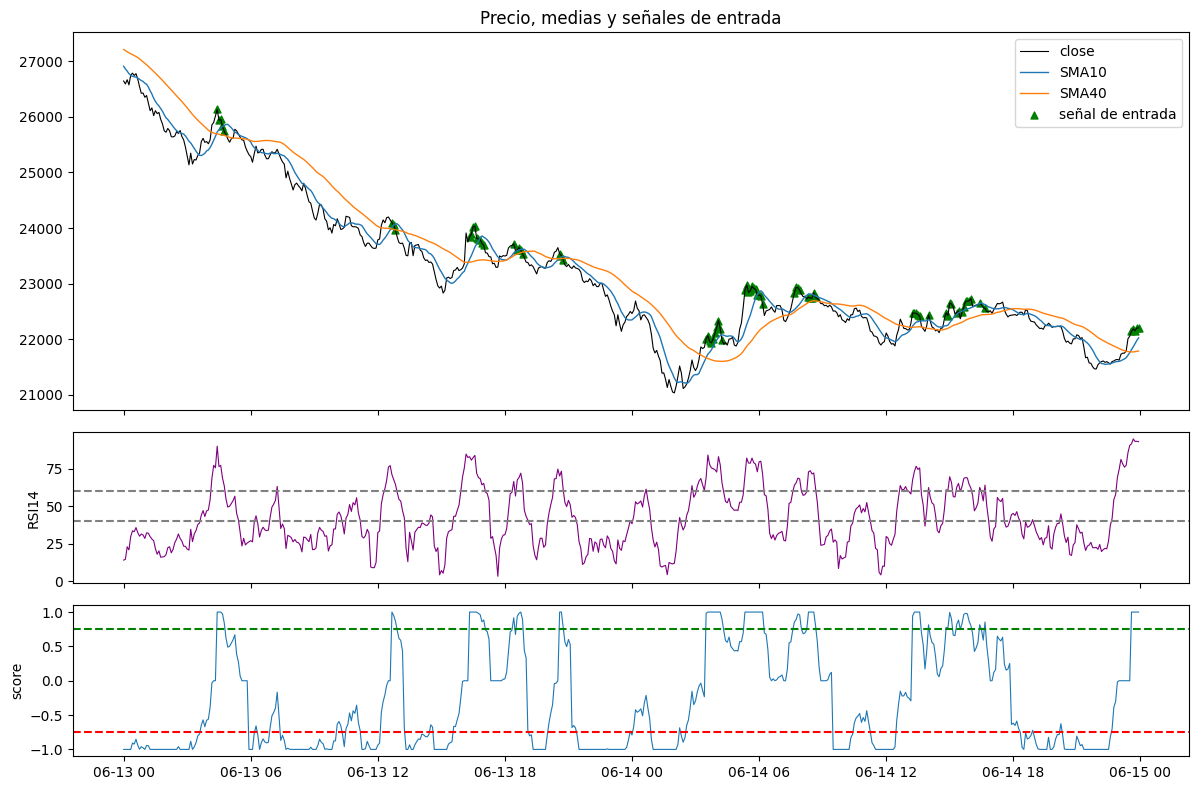

In [8]:
tramo = sig.loc["2022-06-13":"2022-06-14"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
axes[0].plot(tramo.index, tramo["Close"], lw=0.8, color="black", label="close")
axes[0].plot(tramo.index, tramo["sma_fast"], lw=1, label="SMA10")
axes[0].plot(tramo.index, tramo["sma_slow"], lw=1, label="SMA40")
entradas = tramo[tramo["entry_signal"]]
axes[0].scatter(entradas.index, entradas["Close"], marker="^", color="green", s=25, label="señal de entrada")
axes[0].legend(); axes[0].set_title("Precio, medias y señales de entrada")

axes[1].plot(tramo.index, tramo["rsi"], color="purple", lw=0.8)
axes[1].axhline(60, ls="--", color="grey"); axes[1].axhline(40, ls="--", color="grey")
axes[1].set_ylabel("RSI14")

axes[2].plot(tramo.index, tramo["score"], lw=0.8)
axes[2].axhline(0.75, ls="--", color="green"); axes[2].axhline(-0.75, ls="--", color="red")
axes[2].set_ylabel("score")
plt.tight_layout(); plt.show()

En este tramo (13 y 14 de junio de 2022, en plena caída) se ve el problema principal de la estrategia: las señales de entrada se **amontonan en rebotes cortos** dentro de una tendencia bajista. SMA10 cruza por encima de SMA40 por unas horas y el RSI pasa de 60, pero el rebote se agota rápido, así que la estrategia **compra cerca de los máximos locales** (whipsaw).

Hacer tabla con los activos que cumplen y aquellos que no para ver cuando se meten y cuando se salen

## 3. Exit rule, Sizing, Costs y Conventions

| Concepto | Valor |
|---|---|
| Stop-loss | Entrada − 4 × ATR14 |
| Take-profit | Entrada + 8 × ATR14 → **R = 2** |
| Señal opuesta | score ≤ −0.75 → vende en el Open siguiente |
| Holding máximo | 48 barras (4 h) |
| Sizing | Riesgo fijo: `acciones = equity × 0.10 % / (entrada − SL)`, con tope de nocional ≤ 1× equity |
| Comisión | 10 bps por lado (taker de un exchange spot) |
| Slippage | 1 bp por lado |
| Borrow fee | No aplica (solo largo) |
| **Costo ida y vuelta** | **22 bps** |

**Conventions:**
1. La señal se calcula al **cierre de t** y se ejecuta en el **Open de t+1**.
2. Si en una barra se tocan el SL y el TP, se asume que **se tocó primero el stop**, que es el supuesto pesimista.
3. Si la barra abre por debajo del SL, se vende al Open (no al SL).
4. Nunca hay dos posiciones abiertas.

## 4. Win rate de break-even (p*)

Si una operación gana $R$ y pierde $1$ (en unidades de riesgo) y los costos cuestan $c$ en esas mismas unidades:

$$p(R - c) - (1-p)(1 + c) = 0 \;\Rightarrow\; p^* = \frac{1 + c}{1 + R}$$

In [9]:
train_sig = split(sig, "train")
atr_bps_mediano = float((train_sig["atr"] / train_sig["Close"] * 1e4).median())
sl_bps = params.sl_atr_mult * atr_bps_mediano
R = params.tp_atr_mult / params.sl_atr_mult
c = params.round_trip_bps / sl_bps

print(f"ATR14 mediano en train : {atr_bps_mediano:.2f} bps")
print(f"SL mediano (4 x ATR)   : {sl_bps:.1f} bps")
print(f"Costo ida y vuelta     : {params.round_trip_bps:.0f} bps")
print(f"c (costo en unidades R): {c:.3f}")
print(f"p* sin costos          : {1/(1+R):.1%}")
print(f"p* con costos          : {metrics.breakeven_win_rate(R, c):.1%}")

ATR14 mediano en train : 7.27 bps
SL mediano (4 x ATR)   : 29.1 bps
Costo ida y vuelta     : 22 bps
c (costo en unidades R): 0.757
p* sin costos          : 33.3%
p* con costos          : 58.6%


**La estrategia necesita ganar más del 58.6 % de sus operaciones para ser rentable.** Este es el umbral declarado en `SPEC.md`.

## 5. Unit tests

Corremos toda la batería de tests con pytest:

- **(a)** Una posición larga cuyo stop y target caen en la misma barra se cierra como `stop_loss`.
- **(b)** El sizing regresa exactamente el riesgo en dólares presupuestado.
- **(c)** La máquina de estados nunca mantiene dos posiciones abiertas.
- **Golden-file** y **truncamiento** (secciones 6 y 7).

In [10]:
r = subprocess.run([sys.executable, "-m", "pytest", "-v", "--no-header", "-p", "no:cacheprovider", "--color=no"],
                   capture_output=True, text=True)
print(r.stdout[-3500:])

============================= test session starts =============================
collecting ... collected 18 items

tests/test_backtest_golden.py::test_golden_final_equity PASSED           [  5%]
tests/test_backtest_golden.py::test_golden_equity_path PASSED            [ 11%]
tests/test_backtest_golden.py::test_golden_trades PASSED                 [ 16%]
tests/test_backtest_golden.py::test_backtest_is_pure PASSED              [ 22%]
tests/test_strategy.py::test_same_bar_stop_and_target_closes_as_stop_loss PASSED [ 27%]
tests/test_strategy.py::test_same_bar_tie_inside_backtest_is_stop_loss PASSED [ 33%]
tests/test_strategy.py::test_gap_below_stop_exits_at_open_not_at_stop PASSED [ 38%]
tests/test_strategy.py::test_only_target_hit_is_take_profit PASSED       [ 44%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-30000.0-29910.0-0.001] PASSED [ 50%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-100.0-96.0-0.01] PASSED [ 55%]
tests/test_strategy.py

## 6. Golden-file test

Un camino de 7 barras con el equity final **calculado a mano**, sin correr el código. Parámetros: capital 100,000, riesgo 1 %, comisión 10 bps, slippage 0.

| t | Evento | Cálculo en papel | Cash / Equity |
|---|---|---|---|
| 0 | Señal de entrada, ATR = 1 | — | 100,000 |
| 1 | Compra a 100. SL 96, TP 108 | 1,000 / 4 = **250** acciones; comisión 25 | cash 74,975; equity = 74,975 + 250 × 102 = **100,475** |
| 2 | High 109 ≥ 108 → **take-profit** | 250 × 108 = 27,000; comisión 27 | **101,948** |
| 3 | Compra a 106 (ATR = 2). SL 98, TP 122. Low 97 → **stop-loss** | 1,019.48 / 8 = 127.435 acciones | **100,902.52326** |
| 5 | Compra a 100. SL 96. Señal opuesta al cierre | 1,009.03 / 4 = 252.2563 acciones | equity **101,129.5539** |
| 6 | Vende a 103 (señal) | 252.2563 × 103 − comisión | **101,608.0842** |

In [11]:
from tests.test_backtest_golden import golden_bars, GOLDEN_EQUITY, PARAMS as GOLDEN_PARAMS

res_golden = backtest(golden_bars(), GOLDEN_PARAMS)
comparacion = pd.DataFrame({
    "a_mano": GOLDEN_EQUITY,
    "backtest": res_golden.equity["equity"].values,
}, index=golden_bars().index)
comparacion["diferencia"] = comparacion["backtest"] - comparacion["a_mano"]
comparacion

,a_mano,backtest,diferencia
2023-01-01 00:00:00,100000.000000,100000.000000,0.000000e+00
2023-01-01 00:05:00,100475.000000,100475.000000,0.000000e+00
2023-01-01 00:10:00,101948.000000,101948.000000,0.000000e+00
2023-01-01 00:15:00,100902.523260,100902.523260,0.000000e+00
2023-01-01 00:20:00,100902.523260,100902.523260,0.000000e+00
2023-01-01 00:25:00,101129.553937,101129.553937,0.000000e+00
2023-01-01 00:30:00,101608.084154,101608.084154,-4.365575e-10


In [12]:
res_golden.trades[["entry_time", "exit_time", "entry_price", "exit_price", "shares", "exit_reason", "pnl"]]

,entry_time,exit_time,entry_price,exit_price,shares,exit_reason,pnl
0,2023-01-01 00:05:00,2023-01-01 00:10:00,100.0,108.0,250.000000,take_profit,1948.000000
1,2023-01-01 00:15:00,2023-01-01 00:15:00,106.0,98.0,127.435000,stop_loss,-1045.476740
2,2023-01-01 00:25:00,2023-01-01 00:30:00,100.0,103.0,252.256308,signal,705.560894


## 7. Prueba de truncamiento de todo el pipeline

En la Act 04 probamos que **cada indicador suelto** no mira al futuro. Aquí lo probamos para **todo el pipeline**:
indicadores → señales → combinación → backtest.

Para varios $t$, recalculamos todo sobre `df.iloc[:t+1]` y exigimos que score, señales, cash, acciones y equity en $t$ sean **idénticos** a los del cálculo con la muestra completa.

In [13]:
muestra = split(bars, "train").iloc[:6000]
full_sig = compute_signals(muestra, params)
full_res = backtest(full_sig, params)

filas = []
for t in [100, 750, 1500, 2500, 3333, 4200, 5000, 5999]:
    cut_sig = compute_signals(muestra.iloc[: t + 1], params)
    cut_res = backtest(cut_sig, params)
    filas.append({
        "t": t,
        "score_full": full_sig["score"].iloc[t],
        "score_trunc": cut_sig["score"].iloc[t],
        "equity_full": full_res.equity["equity"].iloc[t],
        "equity_trunc": cut_res.equity["equity"].iloc[t],
        "igual": np.allclose(
            [full_sig["score"].iloc[t], full_res.equity["equity"].iloc[t]],
            [cut_sig["score"].iloc[t], cut_res.equity["equity"].iloc[t]],
            rtol=0, atol=0, equal_nan=True),
    })
pd.DataFrame(filas)

,t,score_full,score_trunc,equity_full,equity_trunc,igual
0,100,-0.594807,-0.594807,99902.289747,99902.289747,True
1,750,-0.645726,-0.645726,98945.690413,98945.690413,True
2,1500,0.728254,0.728254,97304.013510,97304.013510,True
3,2500,0.804417,0.804417,96943.418031,96943.418031,True
4,3333,-1.000000,-1.000000,95944.908056,95944.908056,True
5,4200,0.970308,0.970308,95580.530377,95580.530377,True
6,5000,-0.681422,-0.681422,94304.216424,94304.216424,True
7,5999,-1.000000,-1.000000,93754.073942,93754.073942,True


Añadir metricas
win rate 
el costo empirico y el costo anualizado
- Analisis de sensibilidad 
- buscar el breakeven


En todos los puntos la diferencia es **exactamente 0**. Para comprobar que la prueba sí detecta el problema, en el desarrollo se introdujo a propósito un `close.shift(-1)` en la SMA y los dos tests de truncamiento **fallaron**. La prueba funciona.

Un detalle importante: el backtest **no cierra forzosamente** la posición al final de los datos. Si lo hiciera, cobraría la comisión de salida en la última barra y el equity en $t$ cambiaría al truncar.

## 8. Correr la estrategia: train y validation

Los indicadores se calculan sobre toda la serie (son causales, ya lo probamos) y luego se recorta cada conjunto, para que validation no pierda barras de warm-up.

In [14]:
resultados = {}
for nombre in ["train", "validation"]:
    resultados[nombre] = backtest(split(sig, nombre), params)

tabla = pd.DataFrame({n: metrics.summary(r, atr_bps_mediano) for n, r in resultados.items()})
tabla.drop(index="exit_reasons")

,train,validation
final_equity,21621.479897,46433.955897
total_return,-0.783785,-0.53566
annual_return,-0.840993,-0.83961
annual_volatility,0.068792,0.063031
sharpe,-26.695121,-29.003425
max_drawdown,-0.78414,-0.53566
calmar,-1.072504,-1.567429
n_trades,1907,854
trades_per_day,6.273026,5.581699
turnover_annual,1696.431075,1570.960646


In [15]:
for n, r in resultados.items():
    print(n, r.trades["exit_reason"].value_counts().to_dict())

train {'stop_loss': 804, 'take_profit': 508, 'signal': 457, 'max_holding': 138}
validation {'stop_loss': 323, 'signal': 279, 'take_profit': 173, 'max_holding': 79}


### Curva de equity y curva de drawdown

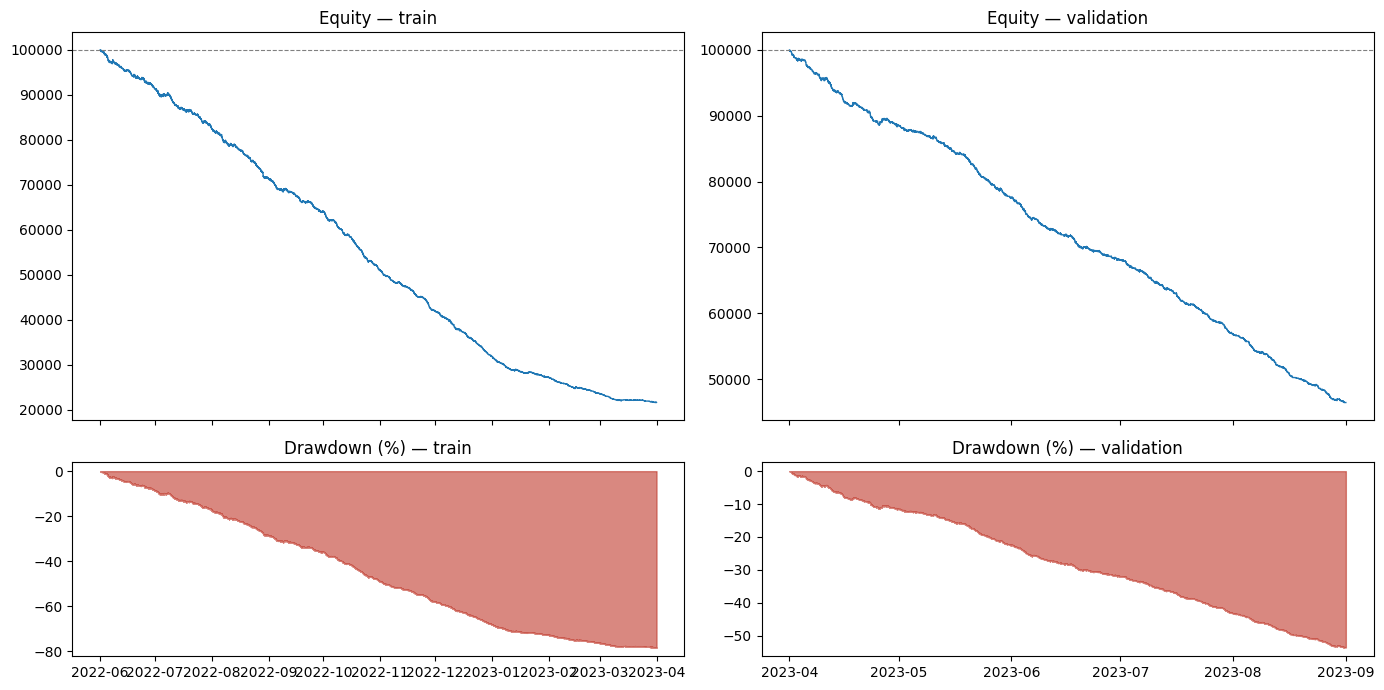

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col", height_ratios=[2, 1])
for j, (n, r) in enumerate(resultados.items()):
    eq = r.equity["equity"]
    axes[0, j].plot(eq.index, eq, lw=1)
    axes[0, j].axhline(params.initial_capital, color="grey", ls="--", lw=0.8)
    axes[0, j].set_title(f"Equity — {n}")
    dd = metrics.drawdown(eq) * 100
    axes[1, j].fill_between(dd.index, dd, 0, color="#c0392b", alpha=0.6)
    axes[1, j].set_title(f"Drawdown (%) — {n}")
plt.tight_layout(); plt.show()

### Lista de operaciones

In [17]:
trades_train = resultados["train"].trades
print("Operaciones en train:", len(trades_train))
trades_train[["entry_time", "exit_time", "entry_price", "exit_price", "shares",
              "stop_loss", "take_profit", "exit_reason", "bars_held", "pnl", "r_multiple"]].head(15)

Operaciones en train: 1907


,entry_time,exit_time,entry_price,exit_price,shares,stop_loss,take_profit,exit_reason,bars_held,pnl,r_multiple
0,2022-06-01 06:40:00,2022-06-01 07:35:00,31606.638863,31561.431431,0.901590,31495.723684,31828.469221,signal,11,-97.710253,-0.977103
1,2022-06-01 09:00:00,2022-06-01 11:00:00,31604.632803,31550.858270,1.131393,31516.332580,31781.233250,signal,24,-132.293858,-1.324232
2,2022-06-01 12:45:00,2022-06-01 14:10:00,31746.410652,31587.396685,0.640147,31590.555740,32058.120474,stop_loss,18,-142.335178,-1.426633
3,2022-06-02 06:00:00,2022-06-02 10:00:00,29864.658042,29907.589020,1.054491,29770.178690,30053.616747,max_holding,48,-17.758973,-0.178253
4,2022-06-02 11:20:00,2022-06-02 13:15:00,30012.586896,29864.476144,0.740523,29878.074060,30281.612566,stop_loss,24,-154.019843,-1.546230
5,2022-06-02 15:20:00,2022-06-02 18:15:00,30164.061025,30229.218963,0.412256,29922.813258,30646.556560,signal,35,1.964259,0.019750
6,2022-06-02 20:15:00,2022-06-02 22:10:00,30322.115892,30517.583919,1.001993,30222.855847,30520.635983,take_profit,24,134.896608,1.356319
7,2022-06-02 22:15:00,2022-06-03 00:10:00,30561.495297,30421.205621,0.745695,30427.938377,30828.609136,stop_loss,24,-150.087828,-1.507016
8,2022-06-03 01:55:00,2022-06-03 03:50:00,30597.913000,30493.663219,0.741850,30463.866125,30866.006751,signal,23,-122.658462,-1.233459
9,2022-06-03 06:00:00,2022-06-03 06:20:00,30545.435097,30481.098069,1.704999,30487.182865,30661.939562,stop_loss,5,-213.744742,-2.152082


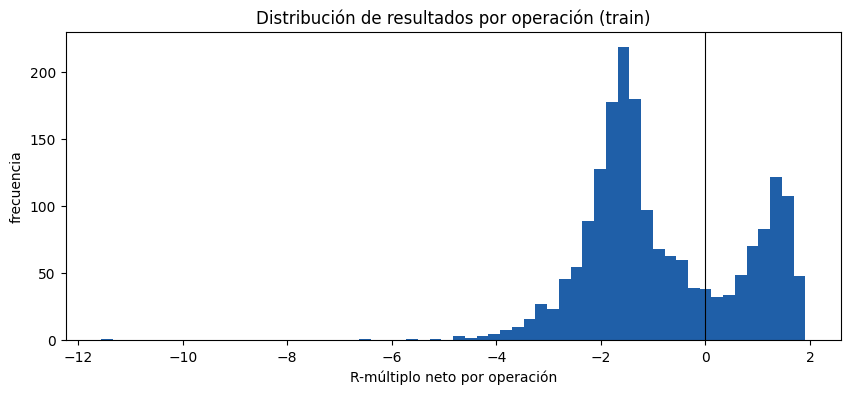

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trades_train["r_multiple"], bins=60, color="#1f5fa8")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("R-múltiplo neto por operación"); ax.set_ylabel("frecuencia")
ax.set_title("Distribución de resultados por operación (train)")
plt.show()

## 9. Sensibilidad a costos (0 a 50 bps ida y vuelta)

Se escalan comisión y slippage manteniendo su proporción del SPEC (10 : 1).

In [19]:
from dataclasses import replace

def params_costo(base, rt_bps):
    por_lado = rt_bps / 2 / 1e4
    frac_fee = base.fee_rate / (base.fee_rate + base.slippage_rate)
    return replace(base, fee_rate=por_lado * frac_fee, slippage_rate=por_lado * (1 - frac_fee))

grid = list(range(0, 55, 5))
sens = {}
for n in ["train", "validation"]:
    s_n = split(sig, n)
    filas = []
    for rt in grid:
        m = metrics.summary(backtest(s_n, params_costo(params, rt)), atr_bps_mediano)
        filas.append({"costo_bps": rt, "sharpe": m["sharpe"], "equity_final": m["final_equity"],
                      "win_rate": m["win_rate_empirical"], "p_star": m["p_star_theoretical"]})
    sens[n] = pd.DataFrame(filas)
sens["train"]

,costo_bps,sharpe,equity_final,win_rate,p_star
0,0,2.775552,114537.581791,0.377239,0.333333
1,5,-4.738789,78838.997858,0.359852,0.390664
2,10,-12.100871,53786.862415,0.342977,0.447994
3,15,-18.712118,36910.504076,0.327731,0.505325
4,20,-24.586689,25171.755443,0.306604,0.562655
5,25,-29.585248,17196.132558,0.285939,0.619986
6,30,-33.922141,11529.783776,0.264752,0.677316
7,35,-37.512219,7753.103086,0.240605,0.734647
8,40,-40.460714,5201.683176,0.221239,0.791977
9,45,-42.750540,3520.852581,0.198231,0.849308


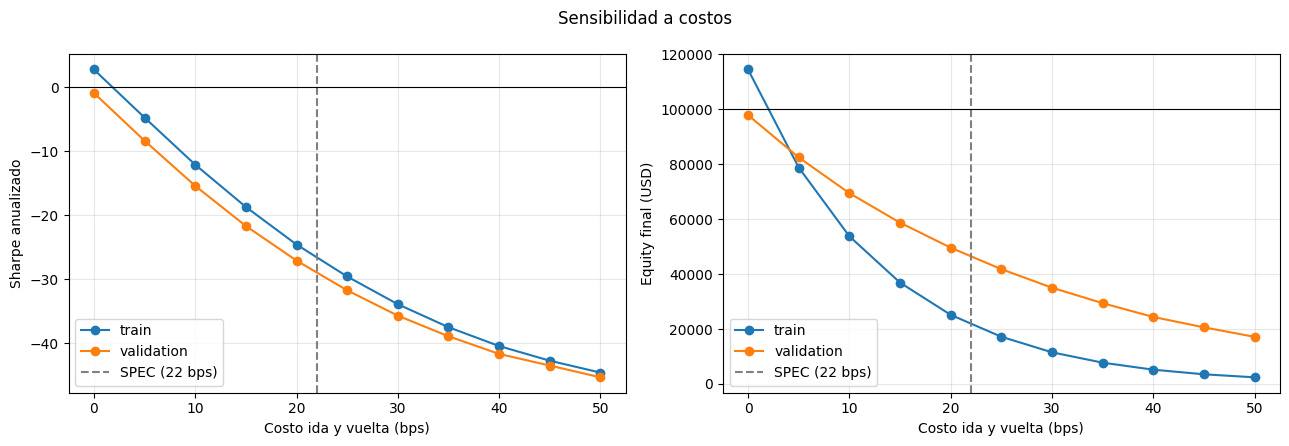

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for n, t in sens.items():
    axes[0].plot(t["costo_bps"], t["sharpe"], marker="o", label=n)
    axes[1].plot(t["costo_bps"], t["equity_final"], marker="o", label=n)
for ax, y in zip(axes, ["Sharpe anualizado", "Equity final (USD)"]):
    ax.axvline(params.round_trip_bps, color="grey", ls="--", label="SPEC (22 bps)")
    ax.set_xlabel("Costo ida y vuelta (bps)"); ax.set_ylabel(y); ax.grid(alpha=0.3); ax.legend()
axes[0].axhline(0, color="black", lw=0.8)
axes[1].axhline(params.initial_capital, color="black", lw=0.8)
plt.suptitle("Sensibilidad a costos"); plt.tight_layout(); plt.show()

## 10. Win rate teórico (p*) vs empírico

In [21]:
wr = pd.DataFrame({
    n: {
        "win_rate_empirico": metrics.win_rate(r.trades),
        "p_star_SPEC": metrics.theoretical_p_star(params, atr_bps_mediano),
        "p_star_con_SL_real": metrics.per_trade_p_star(r.trades, params),
        "SL_promedio_bps": r.trades["sl_distance_bps"].mean(),
        "costo_en_R_por_trade": ((r.trades["entry_fee"] + r.trades["exit_fee"]) / r.trades["risk_dollars"]).mean(),
        "R_bruto_promedio": (r.trades["gross_pnl"] / r.trades["risk_dollars"]).mean(),
    } for n, r in resultados.items()
})
wr

,train,validation
win_rate_empirico,0.296801,0.237705
p_star_SPEC,0.585587,0.585587
p_star_con_SL_real,0.639951,0.641070
SL_promedio_bps,37.699214,35.574121
costo_en_R_por_trade,0.836232,0.839184
R_bruto_promedio,0.000983,-0.098891


### Interpretación

- **El win rate empírico (29.7 % en train, 23.8 % en validation) está muy por debajo de p\* = 58.6 %.** La estrategia no puede ser rentable con estos costos.
- **Sin costos casi empata.** El R-múltiplo **bruto** promedio es ≈ 0 y a 0 bps el Sharpe de train es +2.8, pero en validation es negativo incluso sin costos. No hay una ventaja real que se generalice.
- **Los costos consumen ~0.84 R por operación.** Con un stop promedio de ~38 bps, pagar 22 bps de ida y vuelta equivale a perder casi una unidad de riesgo completa en cada trade. Además, el p\* con el SL real de cada trade (64 %) es mayor que el del SPEC, porque la estrategia tiende a entrar en momentos de baja volatilidad, cuando el stop es más angosto.
- **El break-even de costos está entre 0 y 5 bps**, un nivel que no ofrece ningún exchange minorista con órdenes taker.

**Conclusión:** el motor funciona (golden y truncamiento pasan). El resultado negativo es un problema de **diseño**: operar ~6 veces al día en barras de 5 min con stops de ~30 bps es incompatible con costos de 22 bps.

## 11. Tabla de auditoría de sesgos

| Sesgo | Riesgo | Evidencia concreta |
|---|---|---|
| **Look-ahead** | Bajo | La prueba de truncamiento de todo el pipeline da diferencia 0 en todos los $t$ probados, incluidos los bordes de huecos. La prueba de mutación con `shift(-1)` hace fallar el test. Las señales al cierre de $t$ se ejecutan en el Open de $t+1$. El ATR del SL/TP es el de la barra de señal. No hay cierre forzado al final. |
| **Survivorship** | Medio | Un solo activo, así que no hay universo que filtrar. Pero elegir BTC es una selección *ex post*: es la cripto que sobrevivió cuando en 2022 colapsaron LUNA y FTT. Los resultados no se pueden generalizar a "cripto". Tampoco se sabe qué exchange ni qué agregación usa el dataset (el Open difiere del Close previo en una mediana de 1.4 bps). |
| **Overfitting / data snooping** | Bajo a medio | Una sola configuración probada, sin optimización. Las ventanas SMA10/SMA40/RSI14 se eligieron antes de ver resultados, y θ, los múltiplos de ATR, el riesgo y los costos quedaron fijos en `SPEC.md`. Del train solo se usaron estadísticas descriptivas (ATR mediano y frecuencia de cruces). **Riesgo residual:** se vieron estadísticas descriptivas del precio del periodo de test (fue alcista); la estrategia no se corrió ahí. |
| **Ejecución optimista** | Bajo a medio | Supuestos pesimistas implementados: empate SL/TP → stop (test a); gap bajo el SL → vende al Open (237 de 804 stops en train); gap sobre el TP → sale al TP sin mejora; comisión taker; entradas canceladas si la siguiente barra no tiene precio. **Aún optimista:** 1 bp de slippage en días de crisis (FTX, nov 2022), ejecución sin latencia y liquidez ilimitada en el stop. |
| **Selección / periodo de muestra** | Alto | Train (jun 2022 – mar 2023) es un mercado bajista y de crisis: BTC cayó hasta ~15,600 con FTX y terminó en −10.5 %. Validation fue lateral bajista (−8.9 %). Una estrategia **solo largo** se evaluó en un régimen desfavorable, y el test (sep – dic 2023) es alcista, así que un buen resultado ahí **no** probaría ventaja, solo exposición al rally. Diecinueve meses son un solo ciclo de mercado, y faltan ~3,800 barras. |